In [1]:
!pip install pycuda

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 36.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 10.8 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=8c74cdf3c02bc21426945c1ddd2a4082f0499e0c53165495d76b57b8b1ed9317
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [1]:
import numpy as np
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import time
import matplotlib.pyplot as plt

In [2]:
# 1. CUDA‑ядро для умножения матриц (оптимизированная версия)

cuda_kernel_code = """
__global__ void mulMatrices(const float* matA, const float* matB, float* matC,
                            int rowsA, int colsA, int colsB) {
    // Глобальные индексы потока в сетке
    int rowIdx = blockIdx.y * blockDim.y + threadIdx.y;
    int colIdx = blockIdx.x * blockDim.x + threadIdx.x;

    if (rowIdx < rowsA && colIdx < colsB) {
        float sum = 0.0f;
        // Скалярное произведение строки matA и столбца matB
        for (int k = 0; k < colsA; ++k) {
            sum += matA[rowIdx * colsA + k] * matB[k * colsB + colIdx];
        }
        matC[rowIdx * colsB + colIdx] = sum;
    }
}
"""

In [3]:
# 2. Функция умножения на CPU (тройной цикл)

def cpu_multiply(matrix_left, matrix_right):
    """Умножение матриц на CPU через тройной вложенный цикл.

    Параметры:
        matrix_left  (np.ndarray): левая матрица размером (m, n)
        matrix_right (np.ndarray): правая матрица размером (n, p)

    Возвращает:
        tuple: (результирующая матрица (m, p), время выполнения в секундах)
    """
    m, n = matrix_left.shape
    n2, p = matrix_right.shape
    if n != n2:
        raise ValueError("Размеры матриц не согласованы для умножения")

    result = np.zeros((m, p), dtype=np.float32)

    start = time.perf_counter()
    for i in range(m):
        for j in range(p):
            total = 0.0
            for k in range(n):
                total += matrix_left[i, k] * matrix_right[k, j]
            result[i, j] = total
    elapsed = time.perf_counter() - start

    return result, elapsed

In [4]:
# 3. Функция умножения на GPU с использованием CUDA

def gpu_multiply(matrix_left, matrix_right):
    """Умножение матриц на GPU с помощью CUDA.

    Параметры:
        matrix_left  (np.ndarray): левая матрица размером (m, n)
        matrix_right (np.ndarray): правая матрица размером (n, p)

    Возвращает:
        tuple: (результирующая матрица (m, p), время выполнения в секундах)
    """
    m, n = matrix_left.shape
    n2, p = matrix_right.shape
    if n != n2:
        raise ValueError("Размеры матриц не согласованы для умножения")

    # Преобразование в float32
    matA = matrix_left.astype(np.float32)
    matB = matrix_right.astype(np.float32)
    matC = np.zeros((m, p), dtype=np.float32)

    start = time.perf_counter()

    # Выделение памяти на GPU
    gpuA = cuda.mem_alloc(matA.nbytes)
    gpuB = cuda.mem_alloc(matB.nbytes)
    gpuC = cuda.mem_alloc(matC.nbytes)

    # Копирование данных на GPU
    cuda.memcpy_htod(gpuA, matA)
    cuda.memcpy_htod(gpuB, matB)

    # Компиляция ядра
    module = SourceModule(cuda_kernel_code)
    kernel_func = module.get_function("mulMatrices")

    # Настройка сетки и блоков
    block_x = 16
    block_y = 16
    grid_x = (p + block_x - 1) // block_x
    grid_y = (m + block_y - 1) // block_y

    # Запуск ядра
    kernel_func(gpuA, gpuB, gpuC,
                np.int32(m), np.int32(n), np.int32(p),
                block=(block_x, block_y, 1),
                grid=(grid_x, grid_y))

    # Синхронизация и копирование результата обратно
    cuda.Context.synchronize()
    cuda.memcpy_dtoh(matC, gpuC)

    elapsed = time.perf_counter() - start

    return matC, elapsed

In [5]:
# 4. Проверка корректности и сравнение времени

def test_multiplication(size):
    """Тестирование умножения для заданного размера (квадратные матрицы)."""
    print(f"\nРазмер матрицы: {size}×{size}")

    # Генерация случайных матриц
    A = np.random.rand(size, size).astype(np.float32)
    B = np.random.rand(size, size).astype(np.float32)

    # CPU
    cpu_result, cpu_time = cpu_multiply(A, B)
    print(f"CPU время: {cpu_time:.4f} с")

    # GPU
    gpu_result, gpu_time = gpu_multiply(A, B)
    print(f"GPU время: {gpu_time:.4f} с")

    # Проверка корректности (допустимая погрешность)
    diff = np.abs(cpu_result - gpu_result)
    max_diff = np.max(diff)
    print(f"Максимальное расхождение: {max_diff:.6e}")
    if max_diff < 1e-3:
        print("Результаты совпадают (в пределах погрешности).")
    else:
        print("ВНИМАНИЕ: результаты различаются!")

    return cpu_time, gpu_time

In [7]:
# 5. Проведение экспериментов

sizes = [100, 250, 500, 1000, 1500, 2000]
cpu_times = []
gpu_times = []
speedups = []

for size in sizes:
    cpu_t, gpu_t = test_multiplication(size)
    cpu_times.append(cpu_t)
    gpu_times.append(gpu_t)
    speedups.append(cpu_t / gpu_t)


Размер матрицы: 100×100
CPU время: 0.4041 с
GPU время: 0.0012 с
Максимальное расхождение: 7.629395e-06
Результаты совпадают (в пределах погрешности).

Размер матрицы: 250×250
CPU время: 7.4558 с
GPU время: 0.0013 с
Максимальное расхождение: 1.525879e-05
Результаты совпадают (в пределах погрешности).

Размер матрицы: 500×500
CPU время: 55.3695 с
GPU время: 0.0034 с
Максимальное расхождение: 4.577637e-05
Результаты совпадают (в пределах погрешности).

Размер матрицы: 1000×1000
CPU время: 438.3766 с
GPU время: 0.0130 с
Максимальное расхождение: 7.629395e-05
Результаты совпадают (в пределах погрешности).

Размер матрицы: 1500×1500
CPU время: 1482.8421 с
GPU время: 0.0394 с
Максимальное расхождение: 1.220703e-04
Результаты совпадают (в пределах погрешности).

Размер матрицы: 2000×2000
CPU время: 3378.6633 с
GPU время: 0.0793 с
Максимальное расхождение: 1.831055e-04
Результаты совпадают (в пределах погрешности).


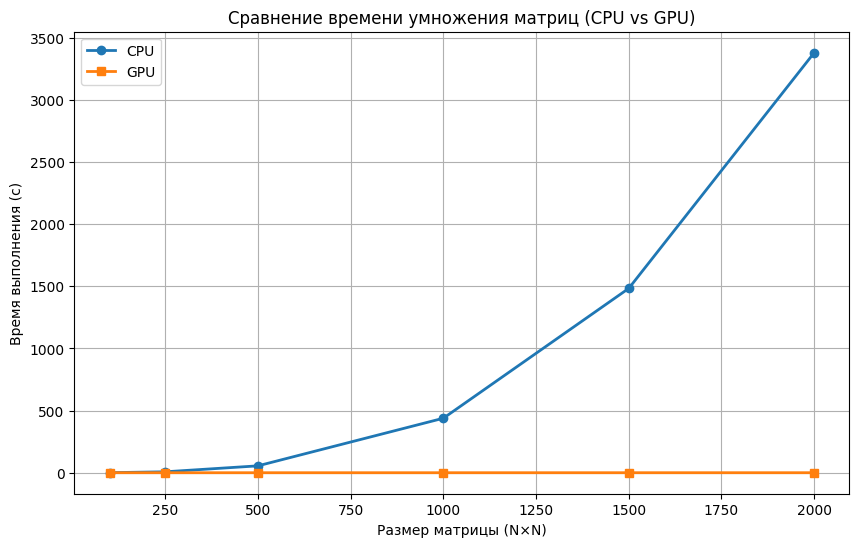

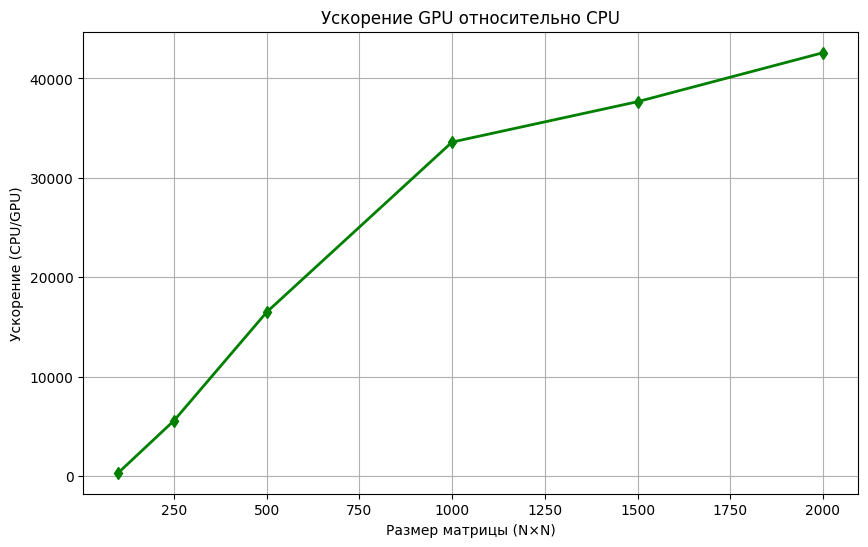

In [8]:
# 6. Визуализация результатов

plt.figure(figsize=(10, 6))
plt.plot(sizes, cpu_times, 'o-', label='CPU', linewidth=2)
plt.plot(sizes, gpu_times, 's-', label='GPU', linewidth=2)
plt.xlabel('Размер матрицы (N×N)')
plt.ylabel('Время выполнения (с)')
plt.title('Сравнение времени умножения матриц (CPU vs GPU)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(sizes, speedups, 'd-', color='green', linewidth=2)
plt.xlabel('Размер матрицы (N×N)')
plt.ylabel('Ускорение (CPU/GPU)')
plt.title('Ускорение GPU относительно CPU')
plt.grid(True)
plt.show()

In [10]:
# 7. Вывод таблицы результатов

print("\nРезультаты экспериментов:")
print("-" * 65)
print(f"{'Размер':^10} | {'CPU время (с)':^15} | {'GPU время (с)':^15} | {'Ускорение':^10}")
print("-" * 65)
for s, ct, gt, sp in zip(sizes, cpu_times, gpu_times, speedups):
    print(f"{s:^10} | {ct:^15.4f} | {gt:^15.4f} | {sp:^10.2f}")
print("-" * 65)



Результаты экспериментов:
-----------------------------------------------------------------
  Размер   |  CPU время (с)  |  GPU время (с)  | Ускорение 
-----------------------------------------------------------------
   100     |     0.4041      |     0.0012      |   335.13  
   250     |     7.4558      |     0.0013      |  5576.04  
   500     |     55.3695     |     0.0034      |  16493.32 
   1000    |    438.3766     |     0.0130      |  33602.13 
   1500    |    1482.8421    |     0.0394      |  37663.59 
   2000    |    3378.6633    |     0.0793      |  42590.13 
-----------------------------------------------------------------
